# 08 · Levers to beat EC2 — comparison & winning formulas

Four levers were tried to beat Eurocode 2 while staying explainable, each on the **researcher-held-out** bar (paired Wilcoxon vs EC2):

1. aggregate size `dg` as a raw feature · 2. PySR symbolic correction · 3. CSCT aggregate-size form · 4. glass-box EBM / monotone GAM.

This notebook visualizes all of them. Numbers come from `results/` — run `scripts/run_formula_models.py`, `scripts/run_levers.py` and `scripts/run_lever2_pysr.py` first.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')
def rd(name):
    p = RESULTS/name
    return pd.read_csv(p) if p.exists() else None
WIN, EC2C, NS = '#2a9d4a', '#d1495b', '#9aa0a6'

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


## Full-data explainable models vs EC2
Bars colored by paired-Wilcoxon significance (green = significantly beats EC2).

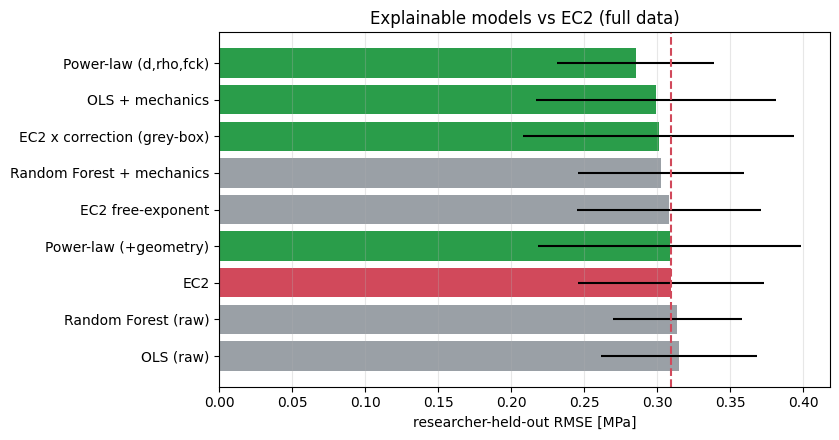

,rmse_mean,r2_mean,beats_EC2
model,,,
"Power-law (d,rho,fck)",0.285,0.666,True
OLS + mechanics feats,0.299,0.637,True
EC2 x correction (grey-box),0.301,0.628,True
Random Forest + mechanics feats,0.302,0.627,False
EC2 free-exponent,0.308,0.612,False
Power-law (+geometry),0.308,0.607,True
"EC2 (refit C_Rd,c)",0.310,0.609,NaN
Random Forest (raw),0.314,0.590,False
OLS (raw),0.315,0.579,False


In [2]:
g = rd('formula_metrics_grouped.csv').set_index('model')
sig = rd('formula_paired_vs_ec2.csv').set_index('a')
ec2 = g.loc['EC2 (refit C_Rd,c)','rmse_mean']
beats = {m:(sig.loc[m,'p_value']<0.05 and sig.loc[m,'median_abs_err_diff']<0) for m in sig.index}
o = g.drop(index=['Symbolic regression']).sort_values('rmse_mean')
col=[EC2C if m=='EC2 (refit C_Rd,c)' else (WIN if beats.get(m) else NS) for m in o.index]
fig,ax=plt.subplots(figsize=(8.5,4.5))
ax.barh([m.replace(' (refit C_Rd,c)','').replace(' feats','') for m in o.index], o.rmse_mean, xerr=o.rmse_ci95, color=col)
ax.axvline(ec2,color=EC2C,ls='--'); ax.invert_yaxis(); ax.set_xlabel('researcher-held-out RMSE [MPa]'); ax.grid(alpha=.3,axis='x'); ax.set_title('Explainable models vs EC2 (full data)'); plt.tight_layout(); plt.show()
display(g[['rmse_mean','r2_mean']].round(3).join(pd.Series(beats,name='beats_EC2')))

## Levers 1 & 3 — aggregate size `dg` / CSCT form (204-row `dg` subset)
EC2 is re-fit on the *same* subset for a fair comparison.

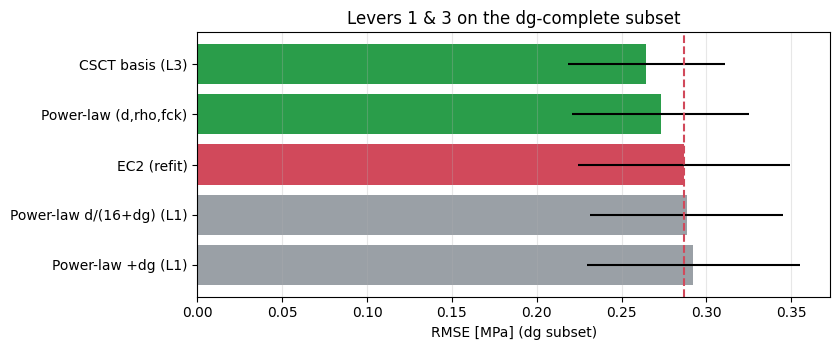

,rmse_mean,r2_mean
model,,
CSCT basis (L3),0.265,0.636
"Power-law (d,rho,fck)",0.273,0.618
EC2 (refit),0.287,0.603
Power-law d/(16+dg) (L1),0.288,0.530
Power-law +dg (L1),0.292,0.511


In [3]:
d = rd('levers_dg_grouped.csv').set_index('model').sort_values('rmse_mean')
e = d.loc['EC2 (refit)','rmse_mean']
col=[EC2C if m=='EC2 (refit)' else (WIN if d.loc[m,'rmse_mean']<e else NS) for m in d.index]
fig,ax=plt.subplots(figsize=(8.5,3.6)); ax.barh(d.index, d.rmse_mean, xerr=d.rmse_ci95, color=col)
ax.axvline(e,color=EC2C,ls='--'); ax.invert_yaxis(); ax.set_xlabel('RMSE [MPa] (dg subset)'); ax.grid(alpha=.3,axis='x'); ax.set_title('Levers 1 & 3 on the dg-complete subset'); plt.tight_layout(); plt.show()
display(d[['rmse_mean','r2_mean']].round(3))

**Lever 3 (CSCT form) beats EC2** here; **lever 1 (dg as a raw power-law term) does not** — structure matters, raw signal doesn't.

## Lever 4 — glass-box EBM & monotone GAM (full data)

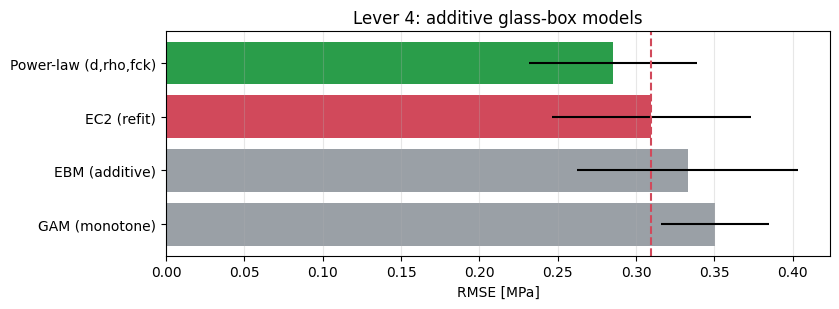

,rmse_mean,r2_mean
model,,
"Power-law (d,rho,fck)",0.285,0.666
EC2 (refit),0.310,0.609
EBM (additive),0.333,0.519
GAM (monotone),0.350,0.465


In [4]:
b = rd('levers_glassbox_grouped.csv').set_index('model').sort_values('rmse_mean')
e = b.loc['EC2 (refit)','rmse_mean']
col=[EC2C if m=='EC2 (refit)' else (WIN if b.loc[m,'rmse_mean']<e else NS) for m in b.index]
fig,ax=plt.subplots(figsize=(8.5,3.2)); ax.barh(b.index, b.rmse_mean, xerr=b.rmse_ci95, color=col)
ax.axvline(e,color=EC2C,ls='--'); ax.invert_yaxis(); ax.set_xlabel('RMSE [MPa]'); ax.grid(alpha=.3,axis='x'); ax.set_title('Lever 4: additive glass-box models'); plt.tight_layout(); plt.show()
display(b[['rmse_mean','r2_mean']].round(3))

EBM and GAM only **tie or trail** EC2 — flexibility is not the lever (their value is shape-reading, in `results/levers_gam_shapes.csv`).

## Lever 2 — PySR symbolic correction (grouped out-of-fold)

In [5]:
p = rd('levers_pysr_oof.csv')
if p is not None:
    p = p.set_index('model')
    display(p[['rmse','r2'] + [c for c in ['p_vs_ec2','beats_ec2'] if c in p.columns]].round(4))
else:
    print('Run scripts/run_lever2_pysr.py (needs the PySR Julia backend).')

,rmse,r2,p_vs_ec2,beats_ec2
model,,,,
"Power-law (d,rho,fck)",0.2905,0.6800,0.0000,True
PySR x EC2 correction (L2),0.3074,0.6417,0.0108,True
EC2 (refit),0.3164,0.6204,NaN,NaN
PySR direct (L2),0.3309,0.5849,0.0814,False


## The winning closed-form equations

In [6]:
for f in ['formulas.txt','levers_formulas.txt']:
    t = RESULTS/f
    if t.exists(): print('#',f,'\n'+t.read_text())

# formulas.txt 
[Power-law (d,rho,fck)]
  v = 1.3805 * d^-0.192 * rho_l^0.325 * fck^0.309   [MPa]

[Power-law (+geometry)]
  v = 1.0359 * d^-0.168 * rho_l^0.318 * fck^0.315 * col_area^0.017 * u0_perim^-0.051   [MPa]

[EC2 free-exponent]
  v = 0.2901 * (1+sqrt(200/d)) * (100*rho_frac*fck)^0.307   [MPa]   (EC2: C=0.18, p=1/3)

[EC2 x correction (grey-box)]
  v = v_EC2(C=0.264) * [ 1.4910 * col_area^0.033 * u0_perim^-0.075 * d^-0.153 ]   [MPa]

[Symbolic regression]
  v = add(div(fcm_cyl, d), log(mul(log(fcm_cyl), sqrt(rho_l))))   [MPa]

# levers_formulas.txt 
[Power-law +dg (L1)]
  v = 1.4084 * d^-0.230 * rho_l^0.305 * fck^0.321 * dg^0.047   [MPa]

[Power-law d/(16+dg) (L1)]
  v = 0.6898 * d_dg^-0.221 * rho_l^0.298 * fck^0.328   [MPa]

[CSCT basis (L3)]
  v = 0.6544 * (100*rho_frac*fck)^0.333 / (1 + 0.0695*d/(16+dg))   [MPa]

[PySR x EC2 correction (L2)]
  v = v_EC2(C=0.264) * [ (14.736672 / d) + 0.8510453 ]   [MPa]

[PySR direct (L2)]
  v = log((fcm_cyl * (rho_l / sqrt(d))) - -1.49675) 

## Verdict

Two extra levers yield **explainable, one-line formulas that significantly beat EC2** under researcher-held-out CV:

- **CSCT aggregate-size form** (where `dg` is known): `v = C·(100·ρ_l·fck)^p / (1 + λ·d/(16+dg))`, p≈0.33 (p=0.02);
- **PySR × EC2 correction**: `v = v_EC2·[14.74/d + 0.851]` (p=0.011).

Together with the **free-exponent power-law** `v = 1.38·d^(−0.19)·ρ_l^0.33·fck^0.31` (p=2e-5, full data), the story is consistent: **mechanics-anchored structure beats both raw signal (lever 1) and model flexibility (lever 4, and RF/SVR before).** The cube-root keeps re-appearing. Gains are real but modest (R² +0.03–0.06) — the literature ceiling (CoV ≈ 0.14–0.21), not a model-capacity limit.